In [1]:
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

model = ChatGoogleGenerativeAI(model = "gemini-2.0-flash")

In [2]:
from typing import TypedDict

class State(MessagesState):
    summary: str

In [3]:
def llm_call(state: State):

    summary = state.get("summary", "")

    if summary:
        
        summary = f"summary of conversation earlier {summary}"
        request = [SystemMessage(content = summary)] + state["messages"]
    
    else:
        request = state["messages"]

    response = model.invoke(request)
    
    return {"messages": response}

In [4]:
def summarize_conversation(state: State):

    summary = state.get("summary","")

    if summary:

        prompt = f"""
                    Can you please summarize this 
                    Old summary: {summary}
                    New Messages: {state["messages"]}
                  """
    else:
        prompt = f"""
                    please sumamrize this: {state["messages"]}
                  """
    response = model.invoke(prompt)
    delete_message = [RemoveMessage(id = m.id) for m in state["messages"][:-2]]
    return {"summary": response, "messages": delete_message}

In [5]:
def should_continue(state: State):

    msg = state["messages"]
    if len(msg) > 6:
        return "summarize_conversation"
    return END

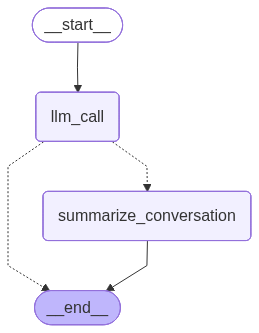

In [6]:
graph = StateGraph(State)

graph.add_node("llm_call", llm_call)
graph.add_node("summarize_conversation", summarize_conversation)

graph.add_edge(START, "llm_call")

# Connect llm_call → summarize_conversation OR end
graph.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "summarize_conversation": "summarize_conversation",
        END: END
    },
)

graph.add_edge("summarize_conversation", END)

memory = MemorySaver()
wf = graph.compile(checkpointer=memory)
wf

In [7]:
config = {"configurable": {"thread_id": 1}}
response = wf.invoke({"messages": [HumanMessage(content = "My name is faizan!")]}, config = config)
response

{'messages': [HumanMessage(content='My name is faizan!', additional_kwargs={}, response_metadata={}, id='aa341195-b362-4d1e-bb65-bddb12a78957'),
  AIMessage(content="Hello Faizan! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--42bd96ac-8cdd-4fb8-9461-a59c57f5c2f9-0')]}

In [8]:
response = wf.invoke({"messages": [HumanMessage(content = "Whats my name?")]}, config = config)
response

{'messages': [HumanMessage(content='My name is faizan!', additional_kwargs={}, response_metadata={}, id='aa341195-b362-4d1e-bb65-bddb12a78957'),
  AIMessage(content="Hello Faizan! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--42bd96ac-8cdd-4fb8-9461-a59c57f5c2f9-0'),
  HumanMessage(content='Whats my name?', additional_kwargs={}, response_metadata={}, id='9d4fbfa4-5e9b-4337-9862-d42a6ab088f6'),
  AIMessage(content='Your name is Faizan.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--52af1ec7-4e47-4028-b143-37905fce7bb0-0')]}

In [9]:
response = wf.invoke({"messages": [HumanMessage(content = "I like to write python code.")]}, config = config)
response

{'messages': [HumanMessage(content='My name is faizan!', additional_kwargs={}, response_metadata={}, id='aa341195-b362-4d1e-bb65-bddb12a78957'),
  AIMessage(content="Hello Faizan! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--42bd96ac-8cdd-4fb8-9461-a59c57f5c2f9-0'),
  HumanMessage(content='Whats my name?', additional_kwargs={}, response_metadata={}, id='9d4fbfa4-5e9b-4337-9862-d42a6ab088f6'),
  AIMessage(content='Your name is Faizan.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--52af1ec7-4e47-4028-b143-37905fce7bb0-0'),
  HumanMessage(content='I like to write python code.', additional_kwargs={}, response_metadata={}, id='3c4f3fdc-9471-4698-bf

In [10]:
response = wf.invoke({"messages": [HumanMessage(content = "its realted to ai and ml")]}, config = config)
response

{'messages': [HumanMessage(content='its realted to ai and ml', additional_kwargs={}, response_metadata={}, id='9cfff397-b614-4d71-94f0-fae9e9be4d06'),
  AIMessage(content="Awesome! AI and ML are incredibly exciting fields. What specifically are you working on in AI/ML with Python? Are you:\n\n*   **Building models?** (e.g., using scikit-learn, TensorFlow, PyTorch)\n*   **Working with data?** (e.g., data cleaning, preprocessing, analysis with pandas and NumPy)\n*   **Developing applications that use AI/ML?** (e.g., chatbots, image recognition apps)\n*   **Just learning the basics?**\n\nKnowing what you're focusing on will help me give you more relevant and helpful information. Let me know what you're up to!", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--5edb732a-cb7d-480f-a44a-840eb77a47b9-0')],
 'summary': AIMessage(content="Faizan introdu